# Customer Churn Deep Dive & Retention Strategy Using Predictive Analytics

### 1. Import Data and Connenct MySQL to Python

In [1]:
import pandas as pd
import mysql.connector
import warnings
warnings.filterwarnings('ignore')

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="churn_db"
)

query = "SELECT * FROM churn_modelling"

df = pd.read_sql(query, conn)

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
df.shape

(10000, 14)

### 2. Data Preprocessing 

In [3]:
# Missing Values
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

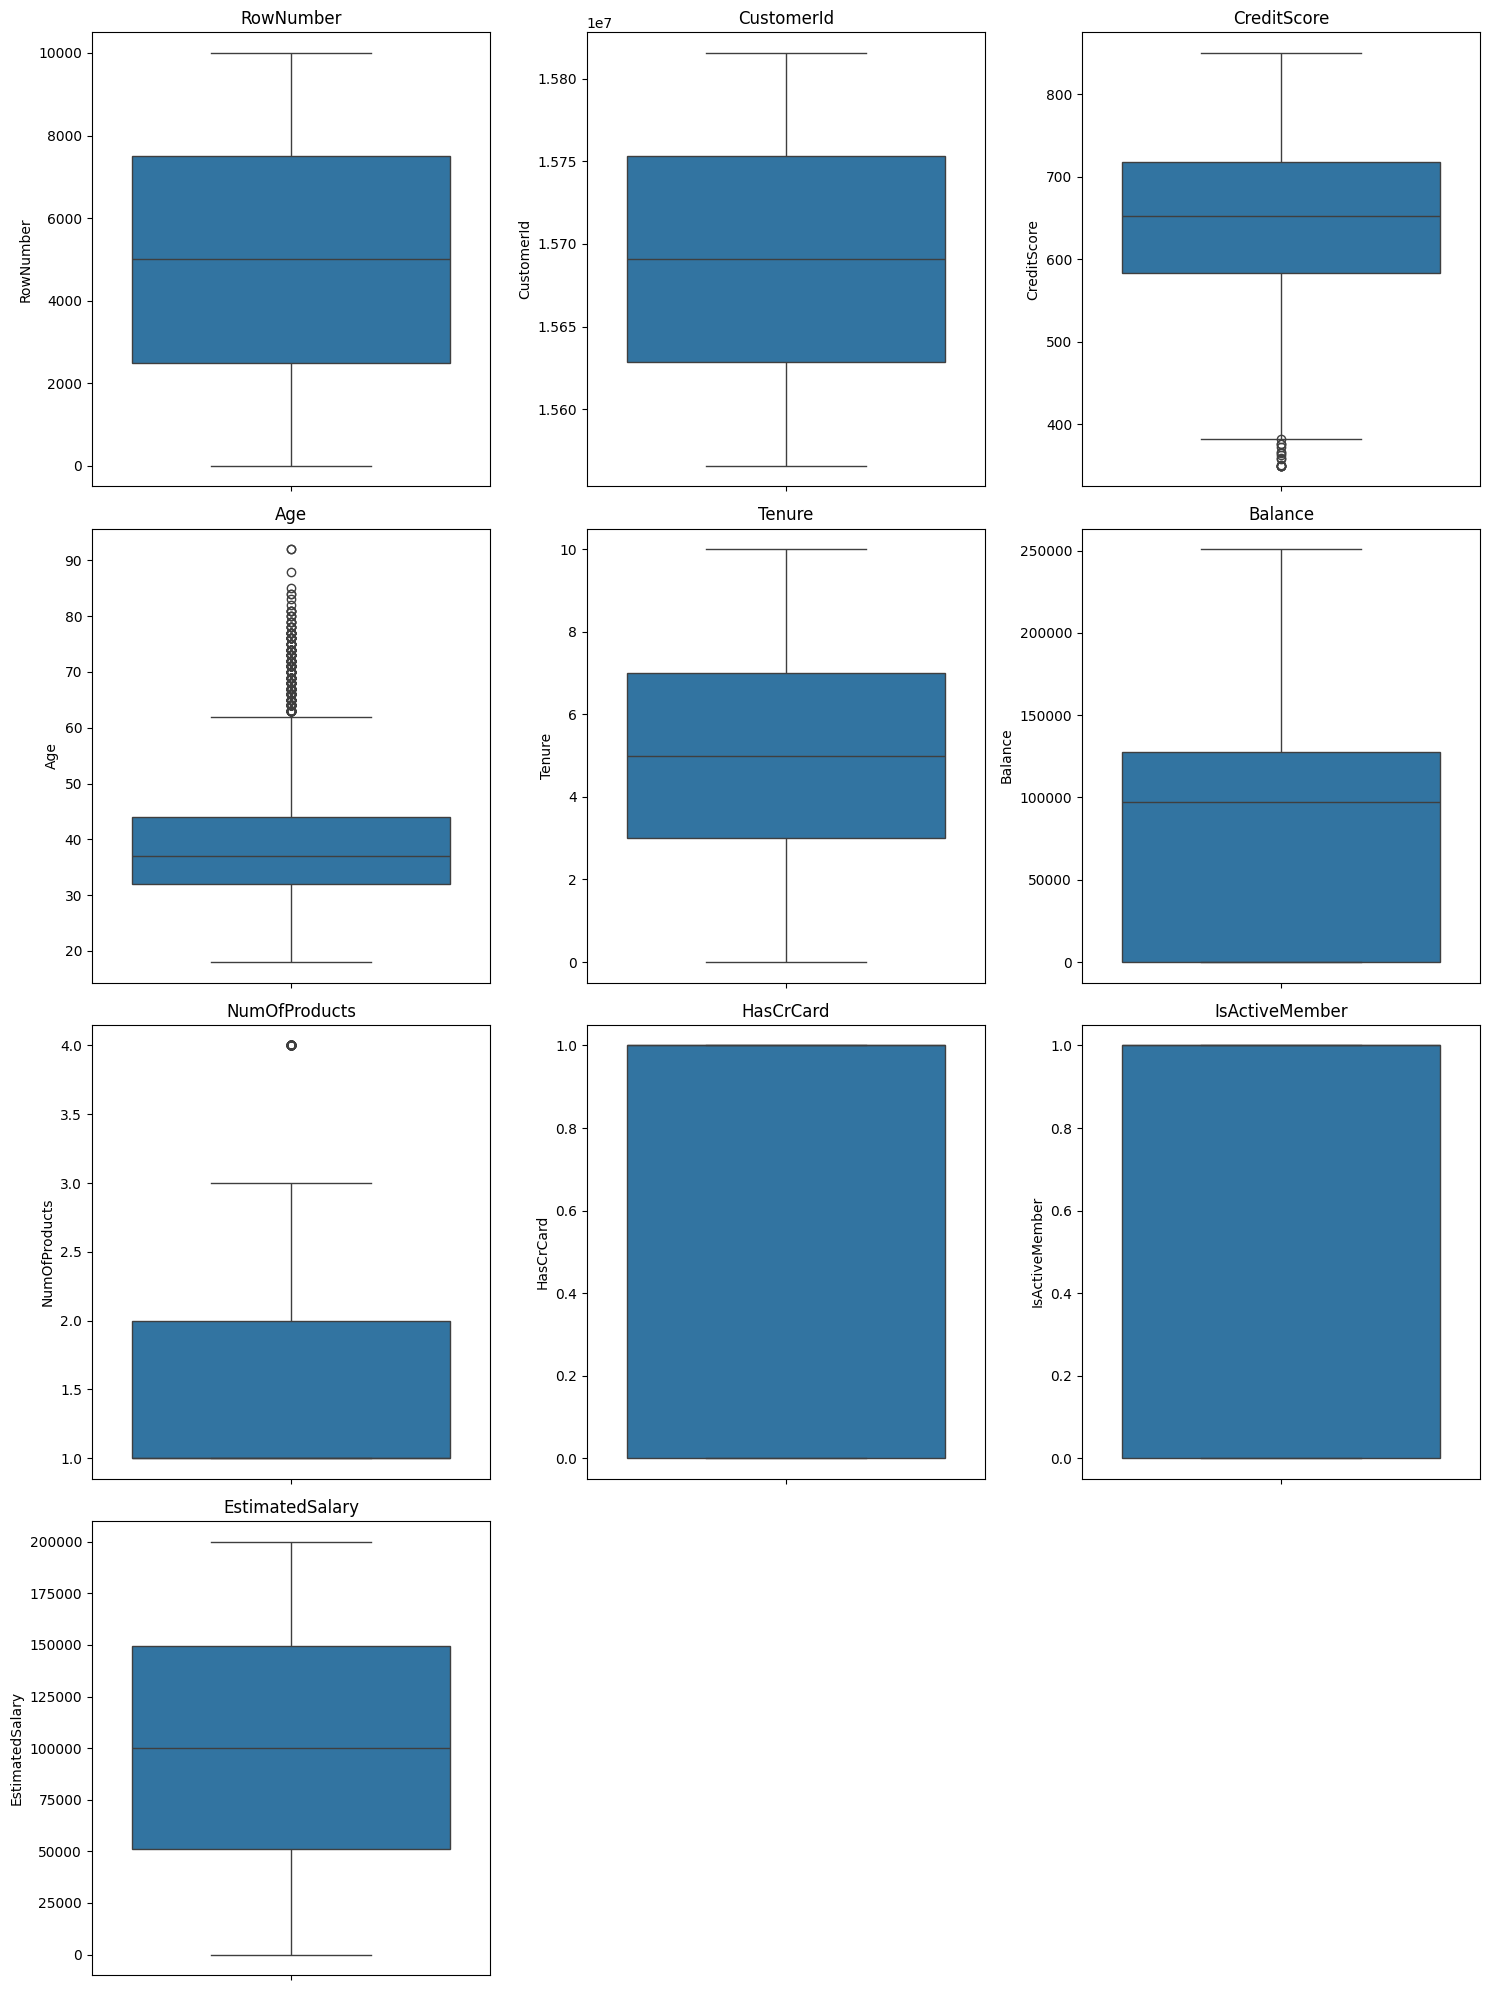

In [4]:
# Checking Outliers
num_cols = df.select_dtypes(include=['number']).columns

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Remove target column
if 'Exited' in num_cols:
    num_cols = num_cols.drop('Exited')

# Calculate number of rows needed
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

### 3. Exploratory Data Analysis 

##### a) Overall Churn rate

In [5]:
churn_rate = df['Exited'].mean() * 100
print("Churn Rate:", churn_rate)

Churn Rate: 20.369999999999997


##### b) Churn Distribution

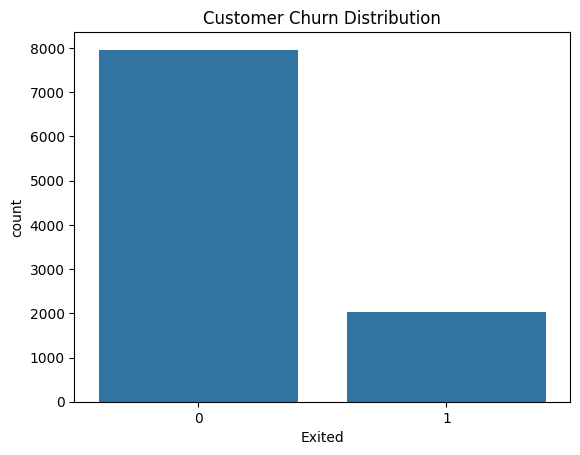

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Exited')

plt.title("Customer Churn Distribution")
plt.show()

**Customer Churn Distribution**
* This is the baseline — it tells you how imbalanced your dataset is.

    * ~8,000 customers stayed (Exited = 0)
    * ~2,000 customers churned (Exited = 1)
    * That's roughly an 80/20 split — a classic class imbalance problem

##### c) Churn by Geography

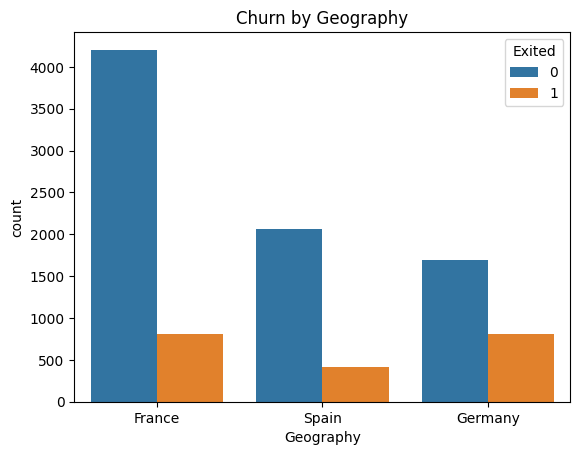

In [7]:
sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title("Churn by Geography")
plt.show()

**Churn by Geography**

* France and Spain have similar, lower churn rates
* **Germany stands out** — despite having fewer total customers, it has nearly as many churners as France, meaning its churn rate is roughly double
* Geography is a strong signal for churn prediction

##### d) Churn by Gender

<Axes: xlabel='Gender', ylabel='count'>

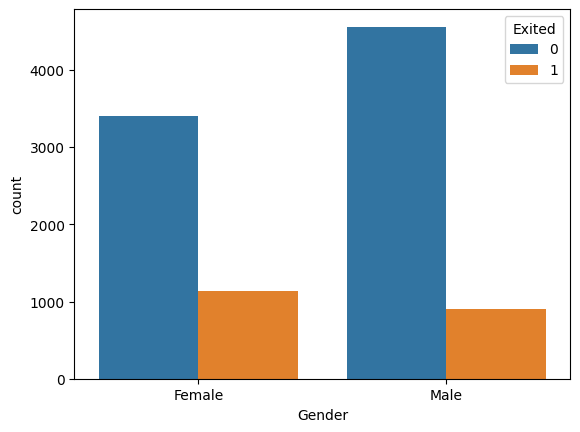

In [8]:
sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

**Churn by Gender**

* Female customers churn at a significantly higher rate than males
* Even though there are more male customers overall, females are leaving disproportionately
* Gender is a meaningful predictor worth including in models

##### e) Age vs Churn

<Axes: xlabel='Exited', ylabel='Age'>

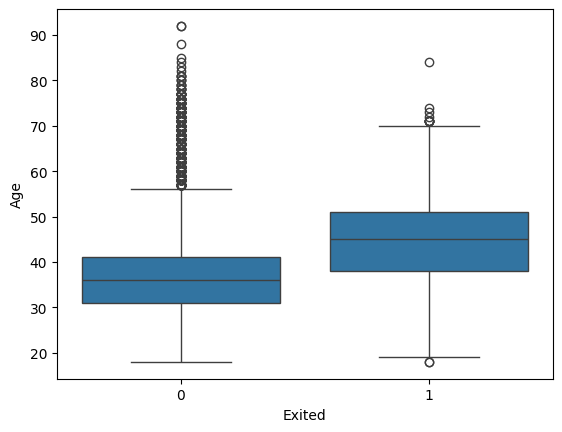

In [9]:
sns.boxplot(
    data=df,
    x='Exited',
    y='Age'
)

**Key Insights**
1. Churners are older

    * Median age of churners (Approx. 45) is noticeably higher than retained customers (Approx 36)
    * The entire box for Exited=1 sits higher on the Y-axis

2. Churners have a tighter, more concentrated age range

    * Exited=0 box is shorter and has many outliers above 60 — retained customers span a wider age range
    * Exited=1 has fewer extreme outliers, meaning churn is more age-specific

3. Older customers (40–55) are the highest-risk segment

    * The IQR for churners falls roughly between 40–52 — this is your core churn-prone demographic

4. Younger customers are less likely to churn

    * The lower whisker for both groups starts around 18–20, but few young customers appear in the churned group relative to retained

##### f) Balance vs Churn

<Axes: xlabel='Exited', ylabel='Balance'>

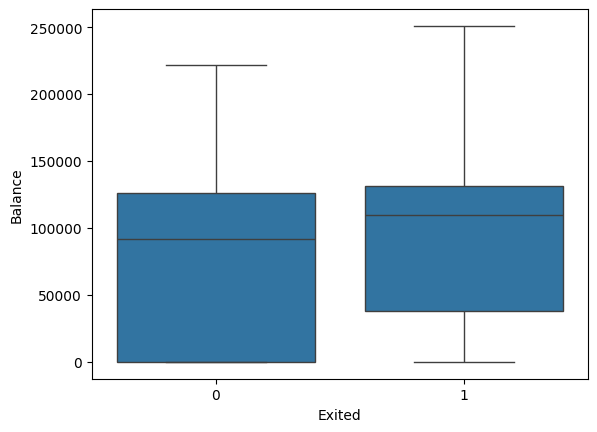

In [10]:
sns.boxplot(
    data=df,
    x='Exited',
    y='Balance'
)

**Balance vs Churn** 

* Key observations:

    * Churners tend to have higher balances — counter-intuitive but important
    * Retained customers have a wide spread reaching near zero, meaning many kept accounts with very low/zero balances
    * Churned customers have fewer near-zero balances — they're not leaving because they're inactive, they're leaving despite having money in the bank
    * This suggests churn is driven by dissatisfaction, not financial inability

##### g) Active Member vs Churn

<Axes: xlabel='IsActiveMember', ylabel='count'>

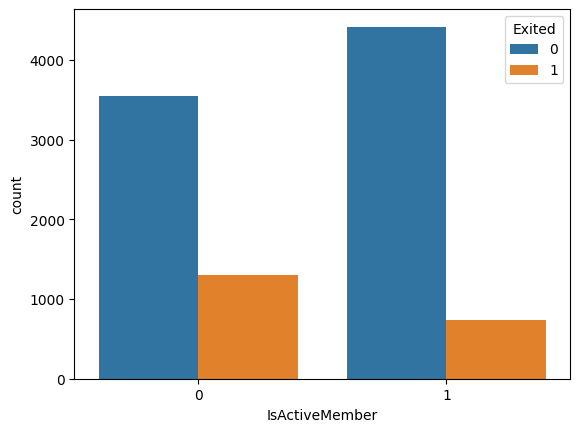

In [11]:
sns.countplot(
    data=df,
    x='IsActiveMember',
    hue='Exited'
)

**Active Member vs Churn**

* Inactive members churn at nearly twice the rate of active members
* This is one of the strongest and most intuitive signals in the dataset
* Being active is clearly a protective factor against churn

### 4. Machine Learning Model

In [12]:
import pandas as pd

# Drop Non-useful columns FIRST
df = df.drop(
    ['RowNumber', 'CustomerId', 'Surname'],
    axis=1
)

# Encode categorical columns
df = pd.get_dummies(
    df,
    columns=['Geography', 'Gender'],
    drop_first=True
)

# Split data
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

import pickle

# Save the trained model
with open("churn_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


##### Accuracy on Train Data

In [13]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_train)

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      6356
           1       0.61      0.21      0.32      1644

    accuracy                           0.81      8000
   macro avg       0.72      0.59      0.60      8000
weighted avg       0.78      0.81      0.77      8000



##### Accuracy on Test Data

In [14]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.58      0.21      0.31       393

    accuracy                           0.81      2000
   macro avg       0.71      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



### 5. Feature Importance

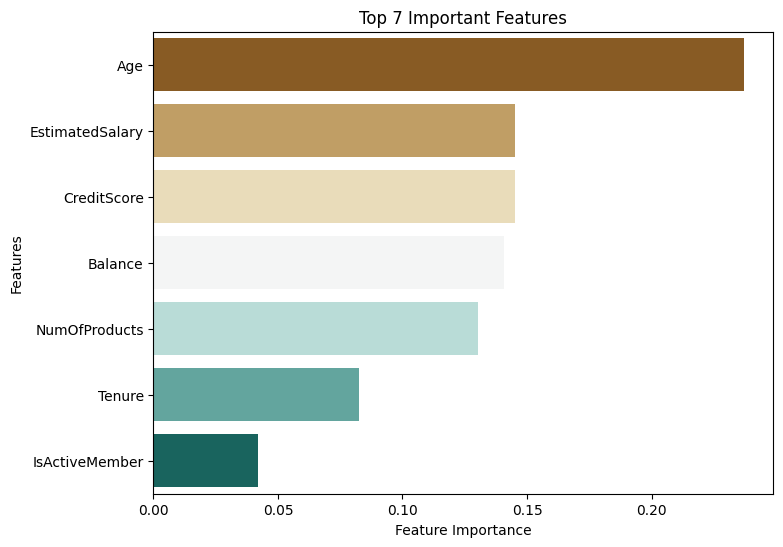

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = feature_importance.head(7)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="BrBG"
)

plt.title("Top 7 Important Features")

plt.xlabel("Feature Importance")

plt.ylabel("Features")

plt.show()

**Key Takeaways**
1. Age dominates (~23% importance)

Confirms what the EDA boxplot already showed — age is the single most powerful churn signal
The model is leaning on age heavily to split churners from non-churners

2. Salary, CreditScore, and Balance are roughly equal (~13–15% each)

These three are almost interchangeable in importance
Together they contribute ~44% of the model's predictive power
They capture the customer's financial profile

3. NumOfProducts matters (~13%)

Customers with fewer or more products behave differently — likely customers with only 1 product churn more easily as they have less "lock-in"

4. IsActiveMember is the weakest here (~4%)

Surprising given the EDA showed a strong visual difference in churn rates
This can happen because the model may already capture the same information through other correlated features (like Tenure or NumOfProducts)